# Model Explainability using Grad-CAM

This notebook visualizes the regions of chest X-ray images that influence the model's pneumonia predictions using Gradient-weighted Class Activation Mapping (Grad-CAM).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/pneumonia_project/pneumonia_resnet50_finetuned.keras"
model = load_model(MODEL_PATH)
print("Model loaded for Grad-CAM.")


Model loaded for Grad-CAM.


In [ ]:
import os
os.makedirs("/content/drive/MyDrive/pneumonia_project/gradcam_results", exist_ok=True)


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


In [ ]:
pneumonia_dir = "/content/drive/MyDrive/pneumonia_project/chest_xray/test/PNEUMONIA"

pneumonia_images = os.listdir(pneumonia_dir)
img_name = random.choice(pneumonia_images)

img_path_pneumonia = os.path.join(pneumonia_dir, img_name)
print("Using PNEUMONIA image:", img_name)

img = image.load_img(img_path_pneumonia, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

heatmap_pneumonia = make_gradcam_heatmap(img_array, model, last_conv_layer_name)


Using PNEUMONIA image: person1640_virus_2839.jpeg


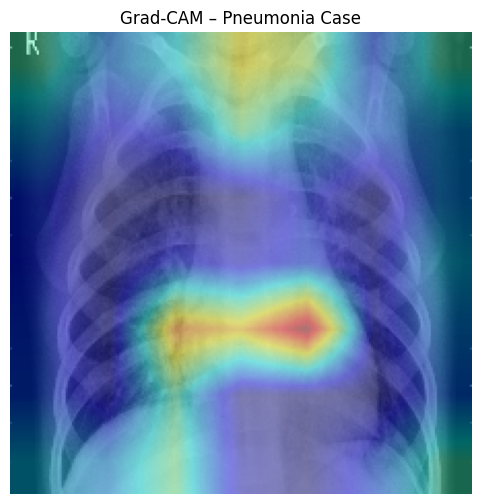

True

In [ ]:
img_original = cv2.imread(img_path_pneumonia)
img_original = cv2.resize(img_original, (224,224))

heatmap = cv2.resize(heatmap_pneumonia, (img_original.shape[1], img_original.shape[0]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img_pneumonia = cv2.addWeighted(img_original, 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(superimposed_img_pneumonia, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Grad-CAM – Pneumonia Case")
plt.show()

cv2.imwrite("/content/drive/MyDrive/pneumonia_project/gradcam_results/gradcam_pneumonia.png",
            superimposed_img_pneumonia)


In [ ]:
import os
import random

normal_dir = "/content/drive/MyDrive/pneumonia_project/chest_xray/test/NORMAL"

normal_images = os.listdir(normal_dir)
img_name = random.choice(normal_images)

img_path_normal = os.path.join(normal_dir, img_name)
print("Using NORMAL image:", img_name)

img = image.load_img(img_path_normal, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

heatmap_normal = make_gradcam_heatmap(img_array, model, last_conv_layer_name)


Using NORMAL image: NORMAL2-IM-0326-0001.jpeg


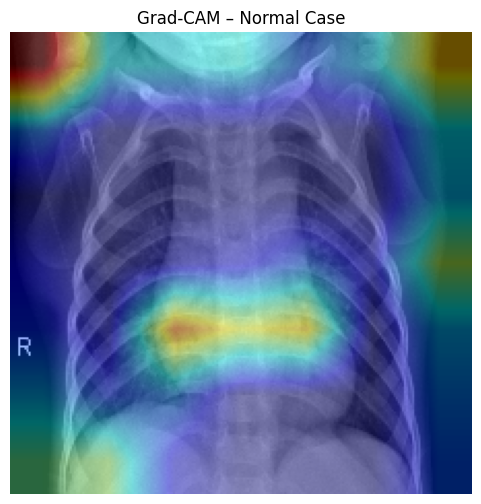

True

In [ ]:
img_original = cv2.imread(img_path_normal)
img_original = cv2.resize(img_original, (224,224))

heatmap = cv2.resize(heatmap_normal, (img_original.shape[1], img_original.shape[0]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img_normal = cv2.addWeighted(img_original, 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(superimposed_img_normal, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Grad-CAM – Normal Case")
plt.show()

cv2.imwrite("/content/drive/MyDrive/pneumonia_project/gradcam_results/gradcam_normal.png",
            superimposed_img_normal)


## Medical Interpretation of Grad-CAM

The highlighted regions in the Grad-CAM visualization correspond to areas in the lungs where the model detects abnormal patterns associated with pneumonia, such as opacities or consolidations. These regions align with areas radiologists typically examine for infection.

In contrast, Grad-CAM for normal chest X-rays shows minimal or diffuse activation, indicating the absence of pneumonia-related abnormalities.

This comparison demonstrates that the model is learning clinically meaningful features and provides transparency into the decision-making process, which is essential for trust in AI-assisted medical diagnosis.
